In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# Add parent directory to path for imports
sys.path.insert(0, "/home/hgf_hmgu/hgf_gib4562/tdmpc2/")

#from analysis.load_run_data import load_run_data
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from rastermap import Rastermap
import numpy as np
from itertools import combinations
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
import pickle
from tqdm import tqdm

from sklearn.linear_model import LinearRegression, Lasso, MultiTaskLasso
from sklearn.metrics import r2_score
import pandas as pd

from analysis.utils import fit_rastermap, plot_rastermap_with_rewards_actions
from analysis.utils import compute_success

In [2]:
import json
from pathlib import Path
import pandas as pd


def flatten_dict(d, parent_key='', sep='_'):
    """
    Flatten a nested dictionary.
    
    Args:
        d: Dictionary to flatten
        parent_key: String to prepend to keys
        sep: Separator between nested keys
    
    Returns:
        Flattened dictionary
    """
    items = []
    for k, v in d.items():
        new_key = f"{parent_key}{sep}{k}" if parent_key else k
        if isinstance(v, dict):
            items.extend(flatten_dict(v, new_key, sep=sep).items())
        else:
            items.append((new_key, v))
    return dict(items)


# Loop over all directories in the sweep logs
sweep_base_dir = Path("logs/111125-latent_interventions_sweep")

all_metadata = []
for sweep_dir in sweep_base_dir.iterdir():
    if sweep_dir.is_dir():
        metadata_path = sweep_dir / "activations" / "episode_0000_metadata.json"
        if metadata_path.exists():
            with open(metadata_path, 'r') as f:
                metadata = json.load(f)
                # Flatten the nested metadata dictionary
                flattened_metadata = flatten_dict(metadata)
                # Add the directory path
                flattened_metadata['directory'] = str(sweep_dir)
                all_metadata.append(flattened_metadata)

print(f"Found {len(all_metadata)} configurations")

# Create DataFrame from flattened metadata
df_metadata = pd.DataFrame(all_metadata)


Found 1260 configurations


In [3]:
df_metadata.head()

,config_id,config_type,config_location,config_num_dims,config_hinge_1_value,config_seed,dims_affected,checkpoint,task,latent_dim,episode_idx,episode_length,total_reward,timestamp,obs_type,directory,config_scale
0,ablationdims200-hinge1_2.32-seed4,ablation,encoder_output,200,2.32,4,"[380, 89, 192, 102, 210, 394, 254, 403, 8, 443...",/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpo...,cartpole-swingup,512,0,500,769.784071,2025-11-11T19:30:09.036350,state,logs/111125-latent_interventions_sweep/2025111...,NaN
1,noisedims10-scale0.1-hinge1_-2.73-seed1,noise,encoder_output,10,-2.73,1,"[47, 345, 284, 221, 503, 168, 223, 189, 378, 192]",/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpo...,cartpole-swingup,512,0,500,894.339316,2025-11-11T20:15:40.630947,state,logs/111125-latent_interventions_sweep/2025111...,0.1
2,noisedims100-scale0.1-hinge1_1.5-seed3,noise,encoder_output,100,1.50,3,"[16, 80, 185, 327, 491, 502, 126, 164, 333, 13...",/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpo...,cartpole-swingup,512,0,500,734.485539,2025-11-11T20:50:39.751113,state,logs/111125-latent_interventions_sweep/2025111...,0.1
3,noisedims200-scale0.1-hinge1_-2.32-seed2,noise,encoder_output,200,-2.32,2,"[355, 331, 301, 317, 322, 165, 244, 152, 415, ...",/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpo...,cartpole-swingup,512,0,500,909.194063,2025-11-11T21:00:58.615257,state,logs/111125-latent_interventions_sweep/2025111...,0.1
4,noisedims300-scale1.0-hinge1_-1.91-seed4,noise,encoder_output,300,-1.91,4,"[380, 89, 192, 102, 210, 394, 254, 403, 8, 443...",/home/hgf_hmgu/hgf_gib4562/tdmpc2/ckpts/cartpo...,cartpole-swingup,512,0,500,360.119539,2025-11-12T00:37:14.211185,state,logs/111125-latent_interventions_sweep/2025111...,1.0


In [4]:
import pickle


def load_intervention_data(df_metadata,
                           type=None,
                           num_dims=None,
                           hinge_1_value=None,
                           seed=None,
                           scale=None):
    """
    Load intervention data from directories matching the specified criteria.
    
    Parameters can be single values or lists. If a parameter is None, it matches all values.
    
    Returns:
        pd.DataFrame: DataFrame with config info and episode data
    """

    # Convert single values to lists for uniform handling
    def to_list(val):
        if val is None:
            return None
        return val if isinstance(val, list) else [val]

    type_list = to_list(type)
    num_dims_list = to_list(num_dims)
    hinge_1_value_list = to_list(hinge_1_value)
    seed_list = to_list(seed)
    scale_list = to_list(scale)

    # Filter configs based on criteria
    filtered_configs = []
    for idx, config in df_metadata.iterrows():
        # Check each criterion
        if type_list is not None and config.get('config_type') not in type_list:
            continue
        if num_dims_list is not None and config.get(
                'config_num_dims') not in num_dims_list:
            continue
        if hinge_1_value_list is not None and config.get(
                'config_hinge_1_value') not in hinge_1_value_list:
            continue
        if seed_list is not None and config.get('config_seed') not in seed_list:
            continue
        if scale_list is not None and config.get(
                'config_scale') not in scale_list:
            continue

        filtered_configs.append(config)

    print(f"Found {len(filtered_configs)} configurations")
    # Load episode data for each matching config
    results = []
    for config in filtered_configs:
        directory = Path(config['directory'])
        episode_path = directory / "activations" / "episode_0000.pkl"

        if episode_path.exists() and metadata_path.exists():
            # Load the pickled episode data
            with open(episode_path, 'rb') as f:
                episode_data = pickle.load(f)

            # Unflatten the data structure
            episode_data = episode_data['data']
            for key, value in episode_data.items():

                if key == 'latent_states':
                    config[key] = value.squeeze()
                else:
                    config[key] = value

            results.append(config)

    return pd.DataFrame(results)


In [5]:
df_ablation = load_intervention_data(df_metadata,
                                     type=['ablation'],
                                     num_dims=[0, 10, 50, 100, 200, 300, 400],
                                     hinge_1_value=None,
                                     seed=[1, 2, 3, 4, 5])

Found 315 configurations


In [6]:
df_noise = load_intervention_data(df_metadata, type=['noise'])
#num_dims=[0, 10, 50, 100, 200, 300, 400],
#hinge_1_value=None,
#seed=[1, 2, 3, 4, 5])

Found 945 configurations


In [13]:
df_noise = compute_success(df_noise)
df_ablation = compute_success(df_ablation)

df_noise['config_hinge_1_value_degrees'] = np.degrees(
    df_noise['config_hinge_1_value'])
df_ablation['config_hinge_1_value_degrees'] = np.degrees(
    df_ablation['config_hinge_1_value'])

df_noise['hinge_str'] = df_noise['config_hinge_1_value_degrees'].round(
    0).astype(str)
df_ablation['hinge_str'] = df_ablation['config_hinge_1_value_degrees'].round(
    0).astype(str)

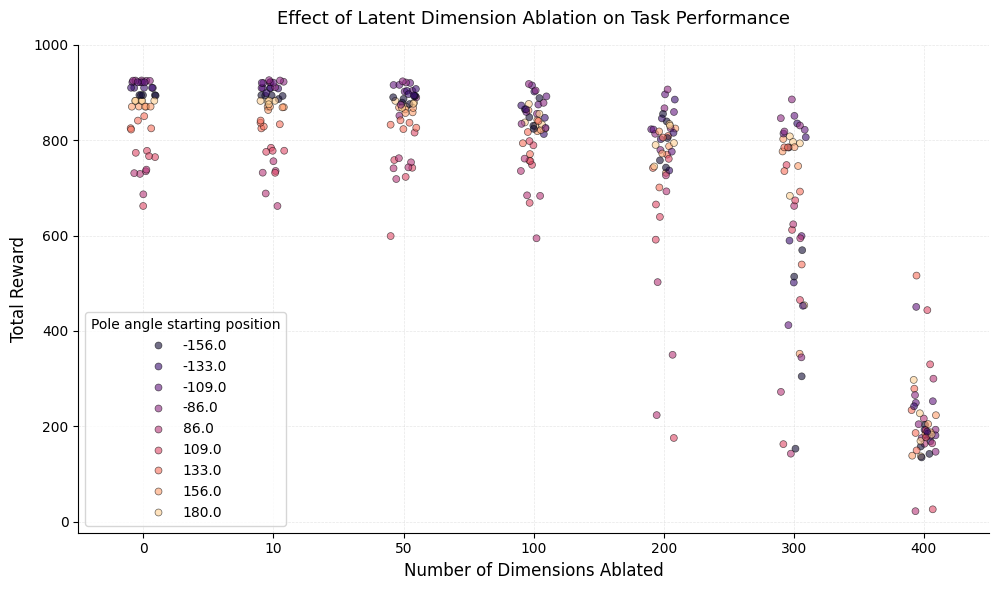

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

# Use seaborn stripplot for better visualization
sns.stripplot(data=df_ablation,
              x='config_num_dims',
              y='total_reward',
              hue='hinge_str',
              palette='magma',
              alpha=0.6,
              s=5,
              edgecolor='black',
              linewidth=0.5,
              hue_order=sorted(df_ablation['hinge_str'].unique(),
                               key=lambda x: float(x)),
              ax=ax,
              legend='brief',
              jitter=True)

ax.set_xlabel('Number of Dimensions Ablated', fontsize=12)
ax.set_ylabel('Total Reward', fontsize=12)
ax.set_title('Effect of Latent Dimension Ablation on Task Performance',
             fontsize=13,
             pad=15)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Update legend title
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Pole angle starting position', loc='best')

plt.tight_layout()
plt.ylim(None, 1000)
plt.show()


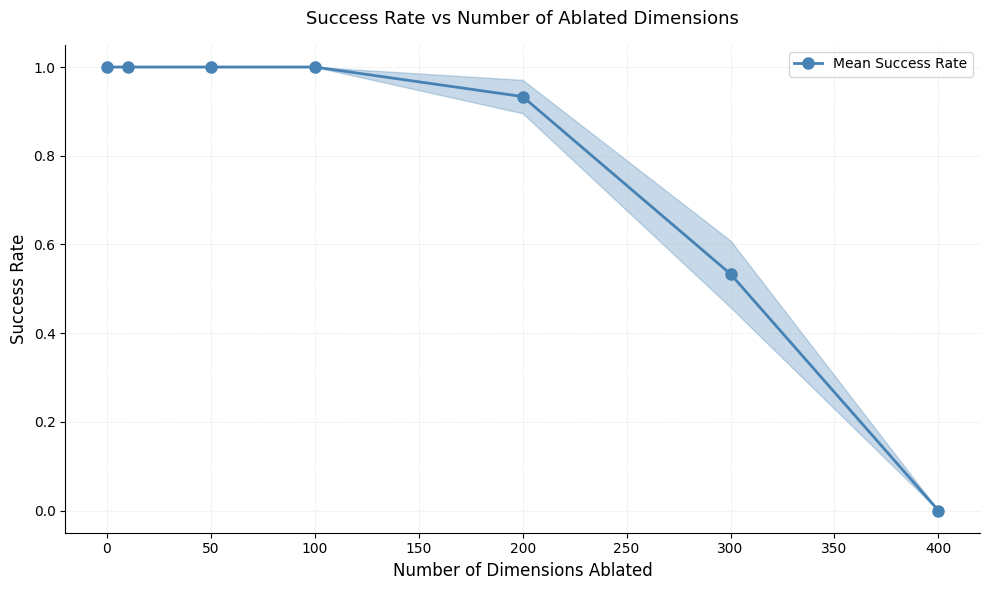

In [17]:
# Compute success for ablation data
df_ablation = compute_success(df_ablation,
                              threshold_angle=0.1,
                              consecutive_steps=100)

# Group by number of dimensions ablated and compute mean success rate
success_by_dims = df_ablation.groupby('config_num_dims')['success'].agg(
    ['mean', 'std', 'count']).reset_index()
success_by_dims['sem'] = success_by_dims['std'] / np.sqrt(
    success_by_dims['count'])

# Create line plot
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(success_by_dims['config_num_dims'],
        success_by_dims['mean'],
        marker='o',
        linewidth=2,
        markersize=8,
        color='steelblue',
        label='Mean Success Rate')

# Add error bars (standard error of the mean)
ax.fill_between(success_by_dims['config_num_dims'],
                success_by_dims['mean'] - success_by_dims['sem'],
                success_by_dims['mean'] + success_by_dims['sem'],
                alpha=0.3,
                color='steelblue')

ax.set_xlabel('Number of Dimensions Ablated', fontsize=12)
ax.set_ylabel('Success Rate', fontsize=12)
ax.set_title('Success Rate vs Number of Ablated Dimensions',
             fontsize=13,
             pad=15)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(-0.05, 1.05)
ax.legend()

plt.tight_layout()
plt.show()


In [91]:
df_noise.keys()

Index(['config_id', 'config_type', 'config_location', 'config_num_dims',
       'config_hinge_1_value', 'config_seed', 'dims_affected', 'checkpoint',
       'task', 'latent_dim', 'episode_idx', 'episode_length', 'total_reward',
       'timestamp', 'obs_type', 'directory', 'config_scale', 'observations',
       'actions', 'rewards', 'dones', 'latent_states', 'timesteps'],
      dtype='object')

In [103]:
hinge1values = df_metadata['config_hinge_1_value'].unique()

In [104]:
hinge1values

array([ 2.32, -2.73,  1.5 , -2.32, -1.91,  2.73, -1.5 ,  3.14,  1.91])

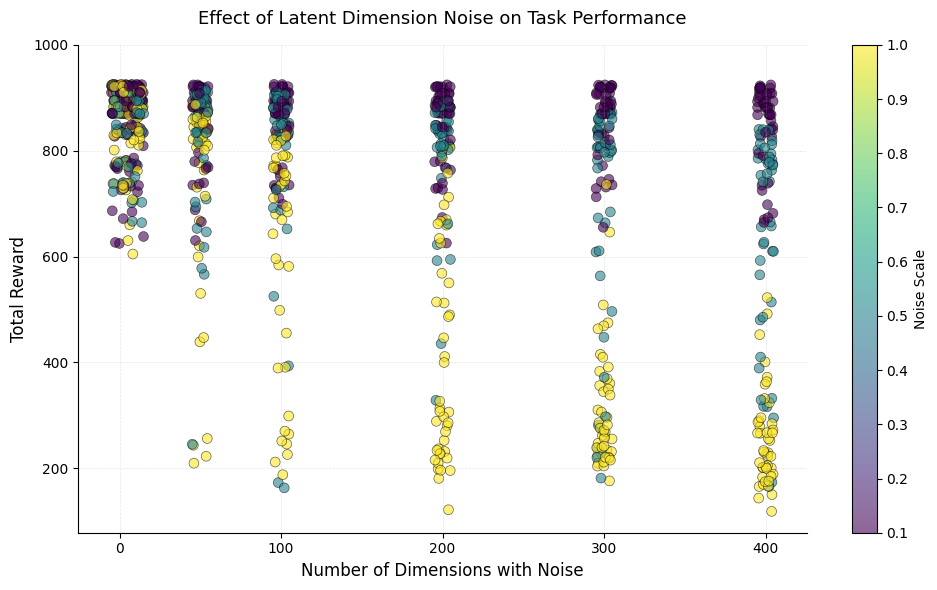

In [155]:
fig, ax = plt.subplots(figsize=(10, 6))

# Add jitter to x-axis to avoid overlapping points
jitter_amount = 5  # Adjust this value to control the amount of jitter
x_jittered = df_noise['config_num_dims'] + np.random.uniform(
    -jitter_amount, jitter_amount, size=len(df_noise))

scatter = ax.scatter(x_jittered,
                     df_noise['total_reward'],
                     c=df_noise['config_scale'],
                     cmap='viridis',
                     alpha=0.6,
                     s=50,
                     edgecolors='black',
                     linewidth=0.5)
cbar = plt.colorbar(scatter, ax=ax, label='Noise Scale')
ax.set_xlabel('Number of Dimensions with Noise', fontsize=12)
ax.set_ylabel('Total Reward', fontsize=12)
ax.set_title('Effect of Latent Dimension Noise on Task Performance',
             fontsize=13,
             pad=15)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.ylim(None, 1000)
plt.show()

In [ ]:
df_noise = load_intervention_data(df_metadata, type=['noise'])

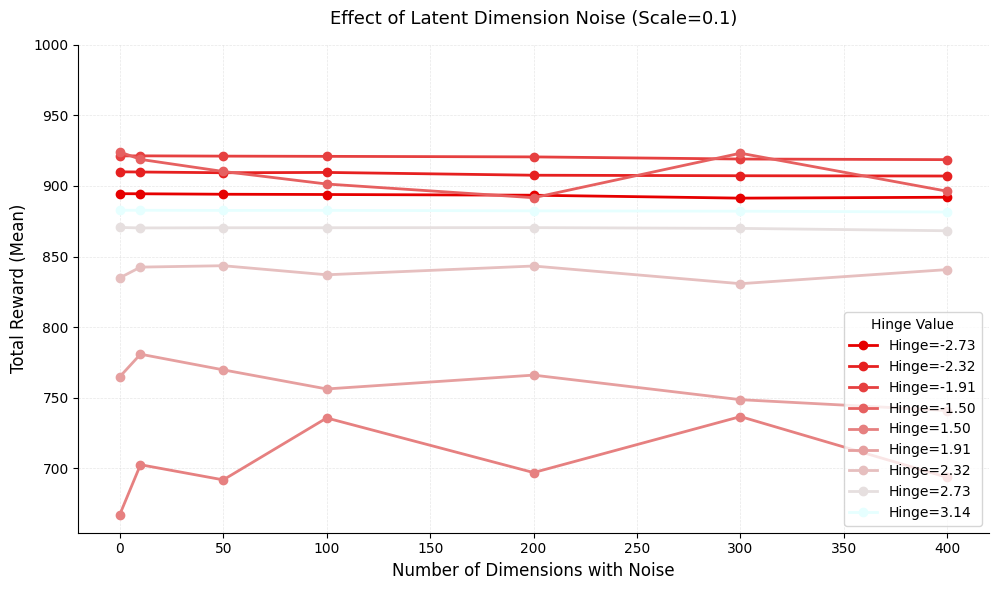

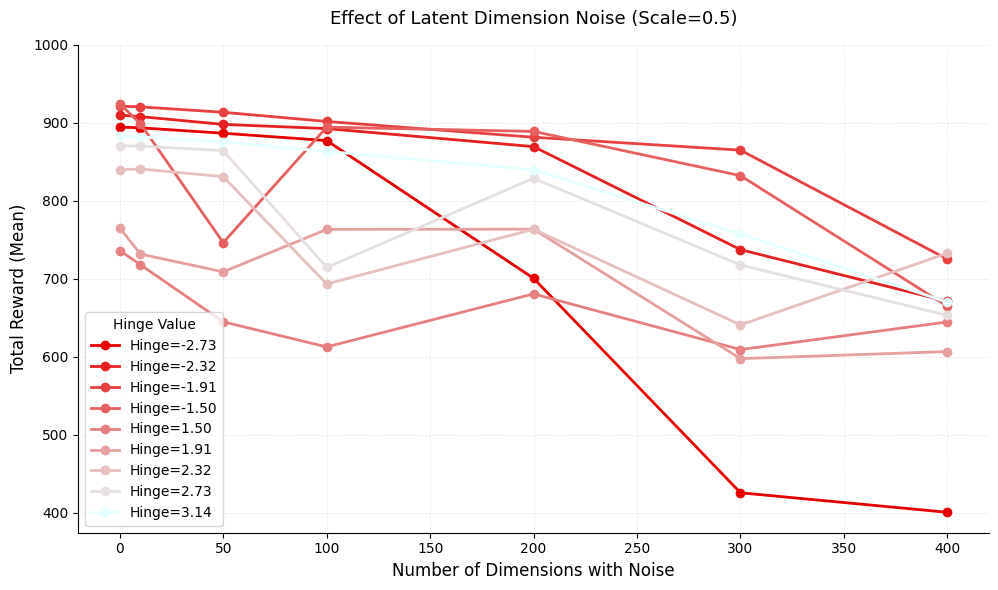

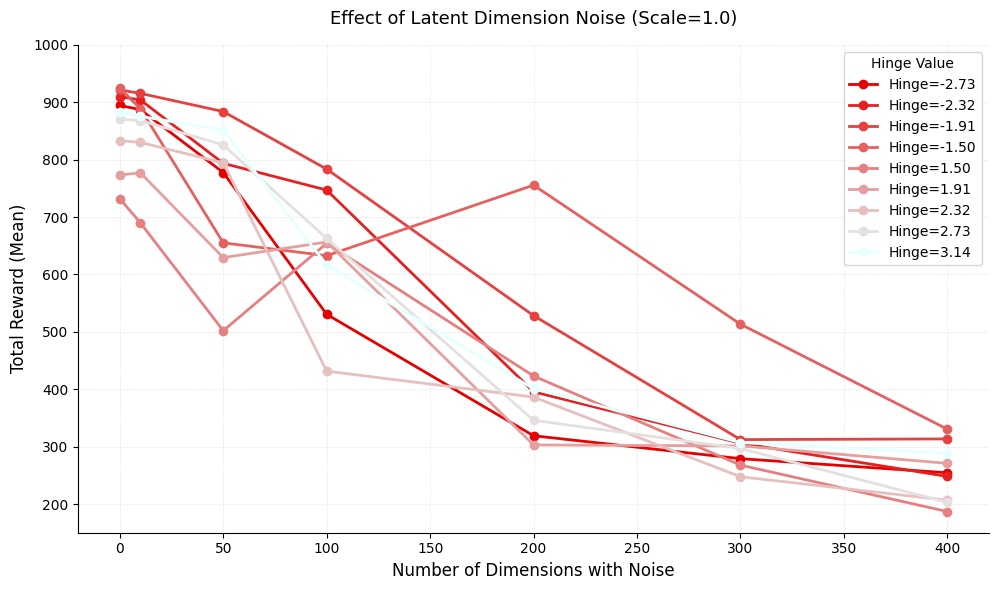

In [113]:
# Get unique scales and hinge values
scales = sorted(df_noise['config_scale'].unique())
hinge_values = sorted(df_noise['config_hinge_1_value'].unique())

# Create a colormap from dark red to light red
import matplotlib.colors as mcolors

n_hinges = len(hinge_values)
colors = [
    mcolors.to_hex((0.9, i / (n_hinges - 1), i / (n_hinges - 1)))
    for i in range(n_hinges)
]

# Create a separate plot for each scale
for scale in scales:
    df_scale = df_noise[df_noise['config_scale'] == scale]

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot one line per hinge value
    for idx, hinge_val in enumerate(hinge_values):
        df_hinge = df_scale[df_scale['config_hinge_1_value'] == hinge_val]

        # Group by num_dims and compute mean across seeds
        mean_rewards = df_hinge.groupby(
            'config_num_dims')['total_reward'].mean()

        ax.plot(mean_rewards.index,
                mean_rewards.values,
                marker='o',
                label=f'Hinge={hinge_val:.2f}',
                linewidth=2,
                markersize=6,
                color=colors[idx])

    ax.set_xlabel('Number of Dimensions with Noise', fontsize=12)
    ax.set_ylabel('Total Reward (Mean)', fontsize=12)
    ax.set_title(f'Effect of Latent Dimension Noise (Scale={scale})',
                 fontsize=13,
                 pad=15)
    ax.legend(title='Hinge Value', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.ylim(None, 1000)
    plt.show()

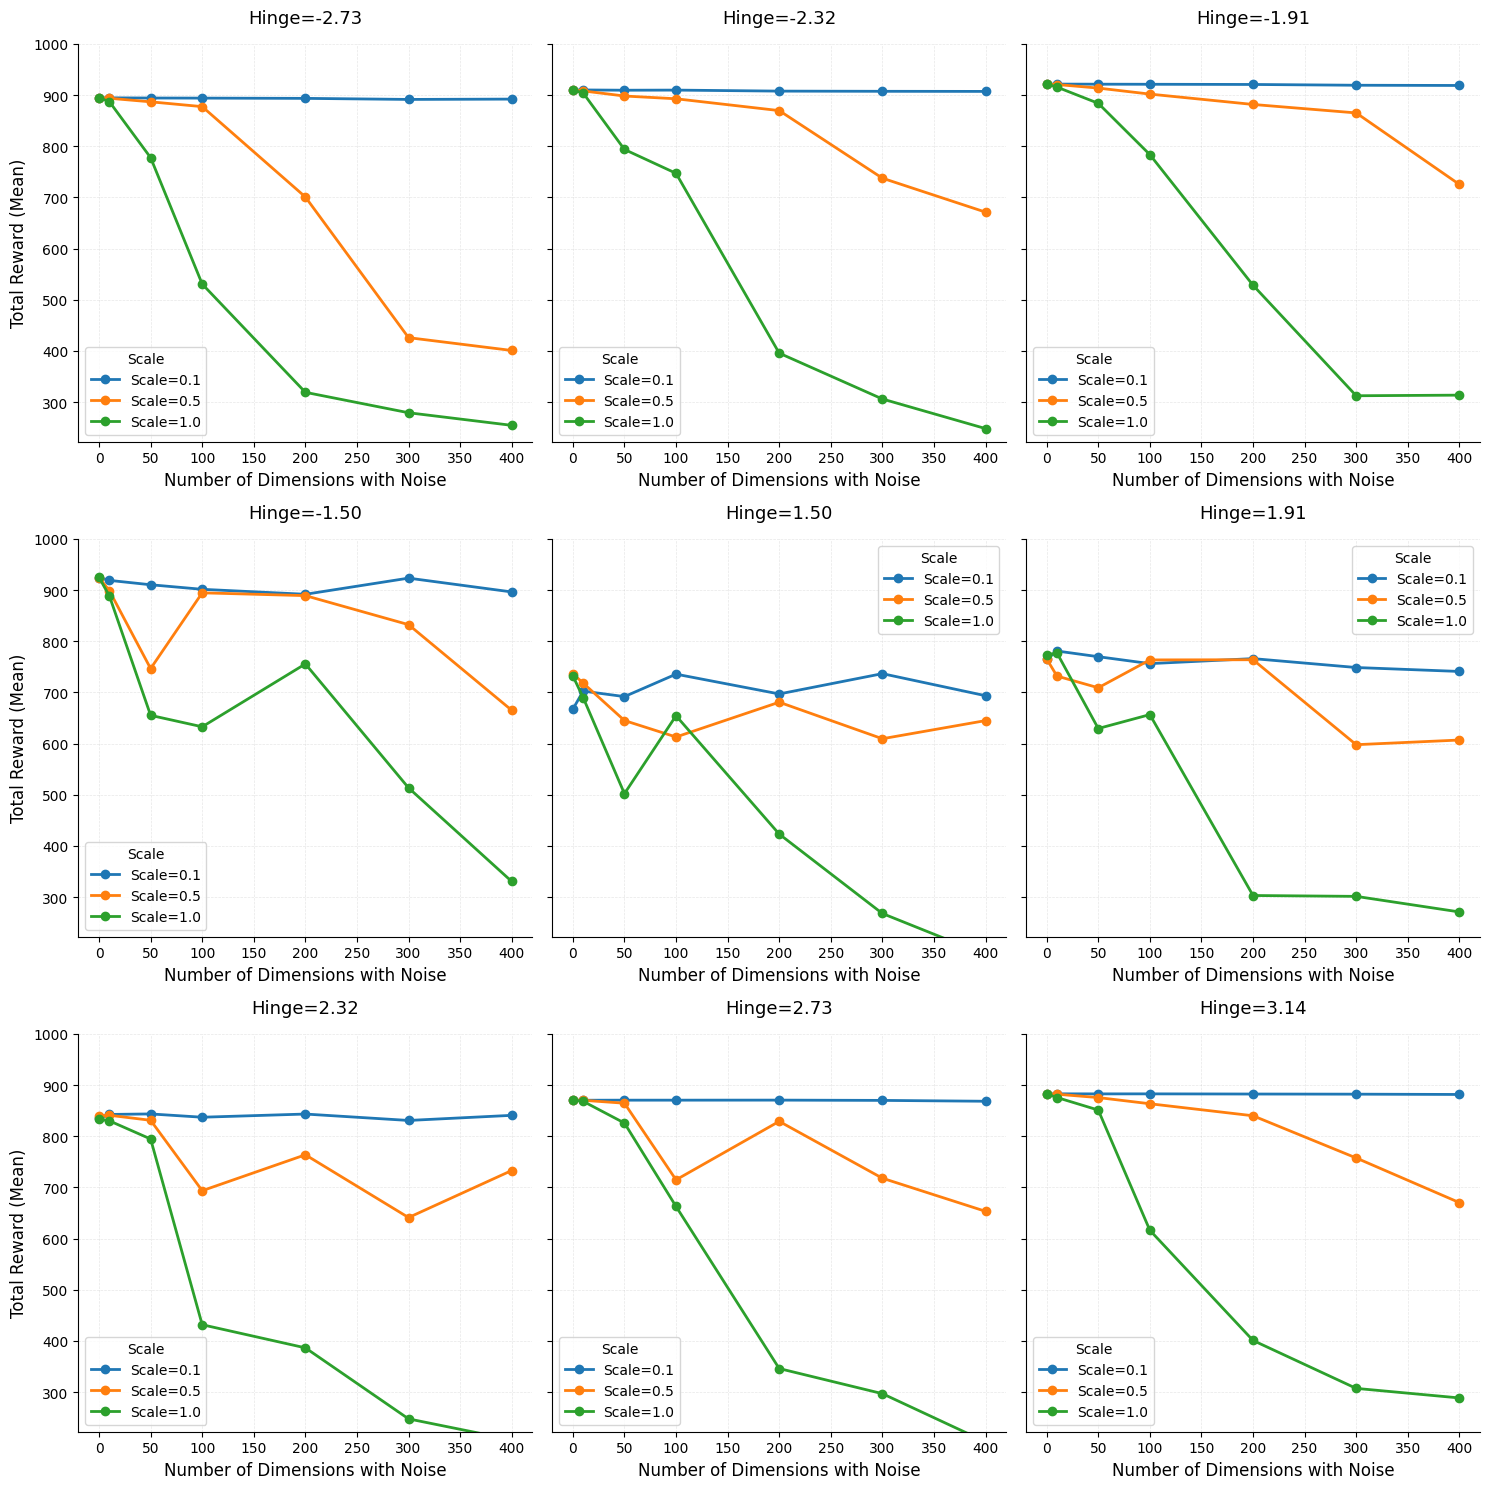

In [116]:
# Get unique scales and hinge values
scales = sorted(df_noise['config_scale'].unique())
hinge_values = sorted(df_noise['config_hinge_1_value'].unique())

# Create a colormap for scales
import matplotlib.colors as mcolors

n_scales = len(scales)
# colors = [
#     mcolors.to_hex((i / (n_scales - 1), 0.2, 0.9 - i / (n_scales - 1)))
#     for i in range(n_scales)
# ]

# Create a grid of subplots with 3 plots per row, sharing y-axis
n_hinge_values = len(hinge_values)
n_cols = 3
n_rows = (n_hinge_values + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows), sharey=True)

# Flatten axes array for easier iteration
if n_rows == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.flatten()

# Plot each hinge value in a separate subplot
for plot_idx, hinge_val in enumerate(hinge_values):
    df_hinge = df_noise[df_noise['config_hinge_1_value'] == hinge_val]

    ax = axes_flat[plot_idx]

    # Plot one line per scale
    for idx, scale in enumerate(scales):
        df_scale = df_hinge[df_hinge['config_scale'] == scale]

        # Group by num_dims and compute mean across seeds
        mean_rewards = df_scale.groupby(
            'config_num_dims')['total_reward'].mean()

        ax.plot(mean_rewards.index,
                mean_rewards.values,
                marker='o',
                label=f'Scale={scale}',
                linewidth=2,
                markersize=6)

    ax.set_xlabel('Number of Dimensions with Noise', fontsize=12)
    if plot_idx % n_cols == 0:  # Only set ylabel for leftmost plots
        ax.set_ylabel('Total Reward (Mean)', fontsize=12)
    ax.set_title(f'Hinge={hinge_val:.2f}', fontsize=13, pad=15)
    ax.legend(title='Scale', fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylim(None, 1000)

# Hide any unused subplots
for plot_idx in range(n_hinge_values, len(axes_flat)):
    axes_flat[plot_idx].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# df_plot = df_noise[(df_noise['config_num_dims'] == 400) &
#                    (df_noise['config_scale'] == 0.1) &
#                    (df_noise['config_hinge_1_value'] == -2.73) &
#                    (df_noise['config_seed'] == 1)]
# latents = df_plot['latent_states'].iloc[0].T

df_plot = df_ablation[(df_ablation['config_num_dims'] == 300) &
                      (df_ablation['config_hinge_1_value'] == -2.73) &
                      (df_ablation['config_seed'] == 1)]
latents = df_plot['latent_states'].iloc[0].T


In [149]:
model, y, isort, X_embedding = fit_rastermap(latents,
                                             n_PCs=200,
                                             n_clusters=100,
                                             locality=0.75,
                                             time_lag_window=10)

2025-11-12 15:28:45,121 [INFO] normalizing data across axis=1
2025-11-12 15:28:45,125 [INFO] projecting out mean along axis=0
2025-11-12 15:28:45,127 [INFO] data normalized, 0.01sec
2025-11-12 15:28:45,127 [INFO] sorting activity: 212 valid samples by 500 timepoints
2025-11-12 15:28:45,150 [INFO] n_PCs = 200 computed, 0.03sec
2025-11-12 15:28:45,199 [INFO] 100 clusters computed, time 0.08sec


/home/hgf_hmgu/hgf_gib4562/miniconda3/envs/tdmpc2/lib/python3.9/site-packages/rastermap/rastermap.py:278: RuntimeWarning: invalid value encountered in divide
  X /= stdx[:,np.newaxis]


2025-11-12 15:29:42,400 [INFO] clusters sorted, time 57.28sec
2025-11-12 15:29:42,442 [INFO] clusters upsampled, time 57.32sec
2025-11-12 15:29:42,446 [INFO] rastermap complete, time 57.32sec


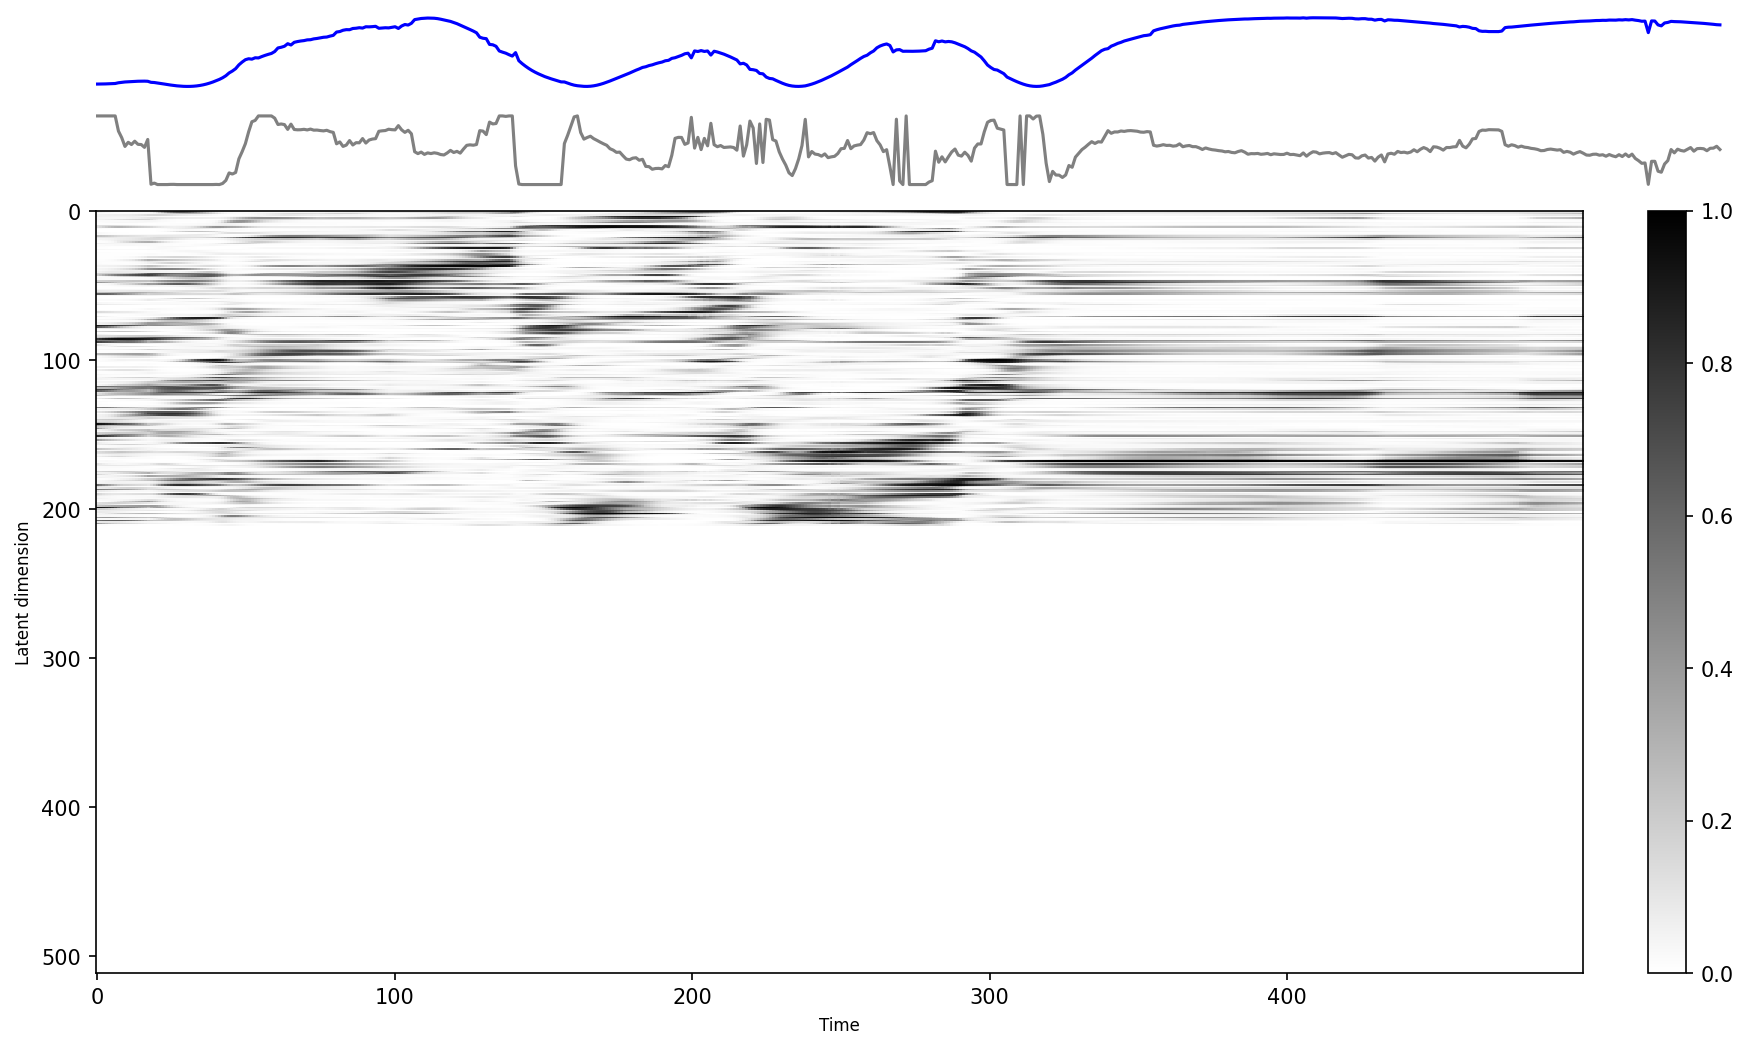

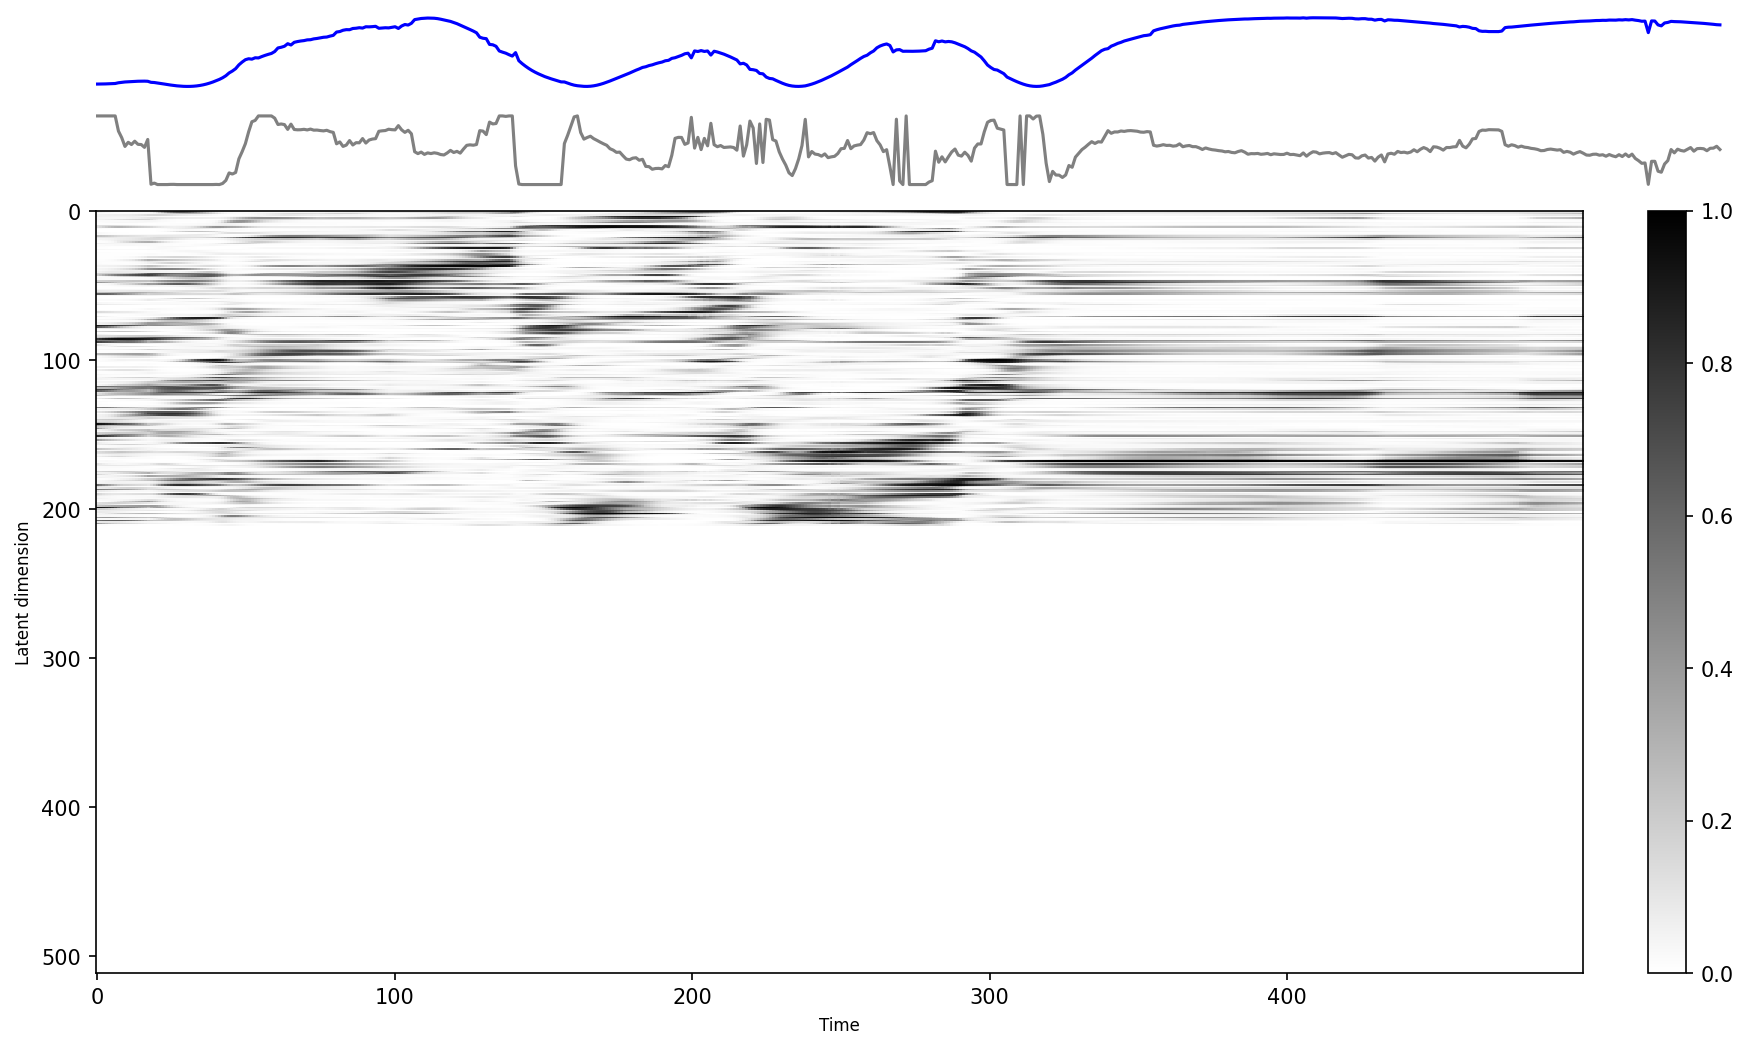

In [150]:
plot_rastermap_with_rewards_actions(X_embedding,
                                    isort,
                                    df_plot.iloc[0]['rewards'],
                                    df_plot.iloc[0]['actions'],
                                    latents=latents,
                                    plot_type='latents',
                                    sort_latents=True)


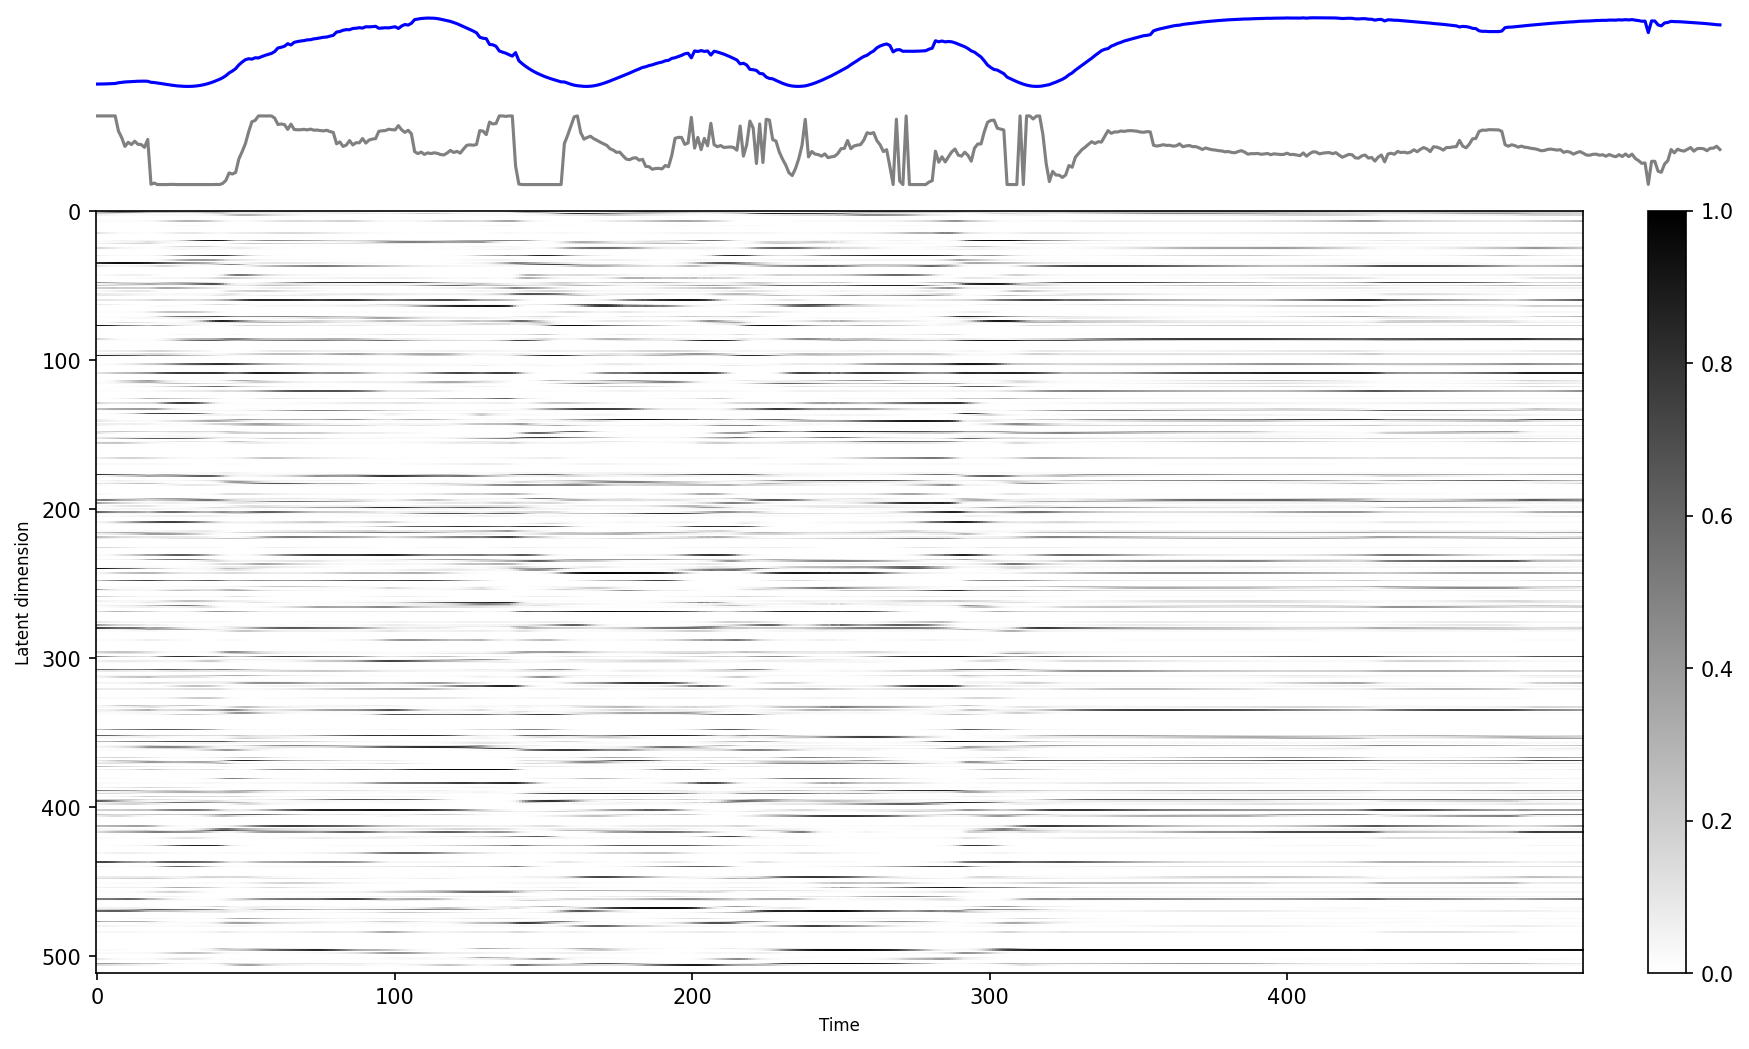

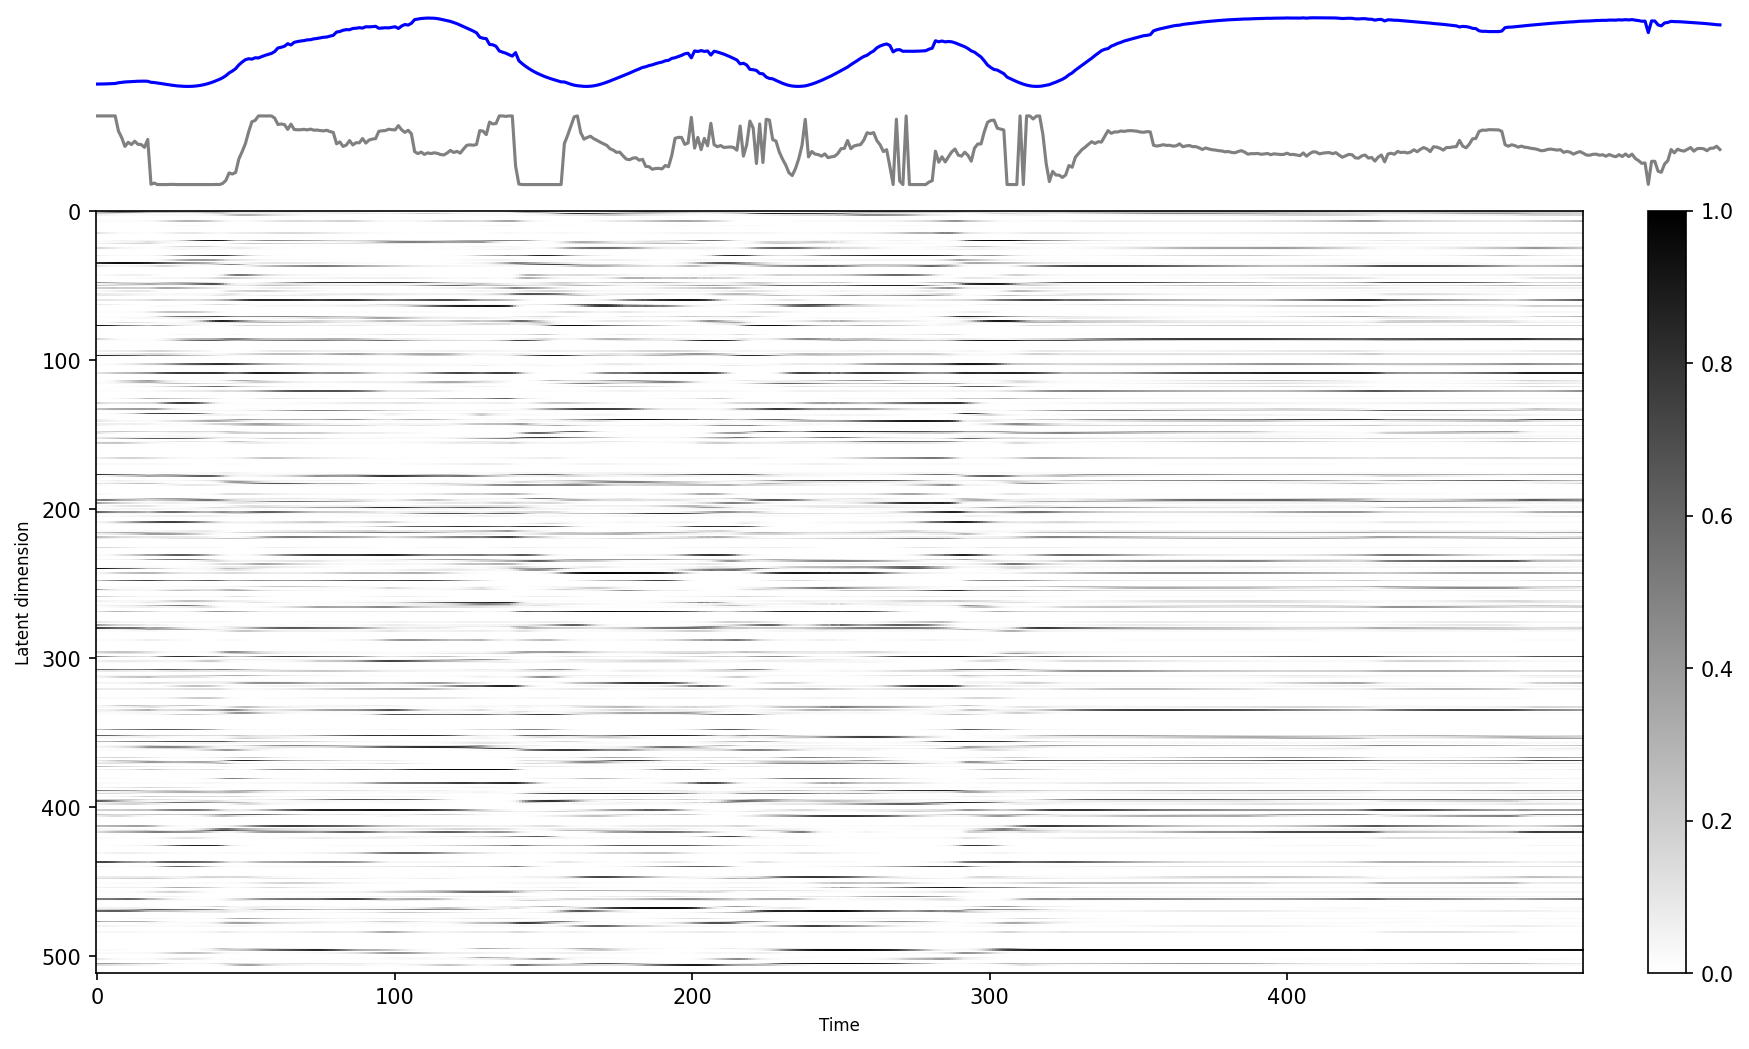

In [151]:
plot_rastermap_with_rewards_actions(X_embedding=None,
                                    isort=None,
                                    rewards=df_plot.iloc[0]['rewards'],
                                    actions=df_plot.iloc[0]['actions'],
                                    latents=latents,
                                    plot_type='latents',
                                    sort_latents=False)